In [1]:
import os
import pandas as pd
import numpy as np
import boto3
from tqdm import tqdm
from passwords import *
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
import sklearn.metrics as skm
from sklearn.linear_model import LinearRegression

### Functions

In [2]:
# download from s3
def download_from_s3(aws_access_key_id, aws_secret_access_key, str_local_path, str_bucket_path, str_project):
    # init client
    cls_client = boto3.client(
        's3',
        aws_access_key_id=aws_access_key_id,
        aws_secret_access_key=aws_secret_access_key,
    )
    # download file
    cls_client.download_file(
        str_project, 
        str_bucket_path, 
        str_local_path,
    )

In [3]:
# make displot
def make_distplot(df, str_title='Distributions of ECNL Predictions'):
    list_cols = [
        '60dpd24_ecnl',
        '15dpd2_ecnl',
    ]
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(str_title)
    ax.set_xlabel('ECNL')
    # all
    for col in list_cols:
        flt_mdn = df[col].median()
        str_label = f'{col}; Mdn = {flt_mdn:0.3f}'
        sns.kdeplot(list(df[col]), label=str_label)
    # legend
    plt.legend()
    # show
    plt.show()

In [4]:
# make scatterplot
def make_scatterplot(df, str_title='Scatterplot of ECNL Predictions'):  
    # constants
    str_x = '60dpd24_ecnl'
    str_y = '15dpd2_ecnl'
    # get spearmanr
    flt_r = spearmanr(df[str_x], df[str_y])[0]
    # update title
    str_title = f"""
    {str_title}
    Spearman r = {flt_r:0.4f}
    """
    # plot
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(str_title)
    ax.set_xlabel(str_x)
    ax.set_ylabel(str_y)
    ax.scatter(df[str_x], df[str_y])
    # show
    plt.show()

In [5]:
# get metrics
def get_metrics(df):
    y_true = df['60dpd24_ecnl']
    y_hat = df['15dpd2_ecnl']
    dict_eval_metrics = {
        'explained_variance': skm.explained_variance_score(y_true=y_true, y_pred=y_hat),
        'mae': skm.mean_absolute_error(y_true=y_true, y_pred=y_hat),
        'mse': skm.mean_squared_error(y_true=y_true, y_pred=y_hat),
        'rmse': np.sqrt(skm.mean_squared_error(y_true=y_true, y_pred=y_hat)),
    }
    # make df
    df_tmp = pd.DataFrame({
        'Metric': list(dict_eval_metrics.keys()),
        'Score': list(dict_eval_metrics.values()),
    })
    # return
    return df_tmp, dict_eval_metrics['rmse']

In [6]:
# show added factors
def show_best_added_factor(df, str_title='Score by Added Factor'):
    list_dict_row = []
    for flt_factor in tqdm(list_flt_factor):
        # add factor
        df['tmp'] = df['15dpd2_ecnl'] + flt_factor
        # get score
        y_true = df['60dpd24_ecnl']
        y_hat = df['tmp']
        flt_score = np.sqrt(skm.mean_squared_error(
            y_true=y_true, 
            y_pred=y_hat,
        ))
        # dict row
        dict_row = {
            'Factor': flt_factor,
            'Score': flt_score,
        }
        list_dict_row.append(dict_row)
    # df
    df_tmp = pd.DataFrame(list_dict_row)
    # plot
    fig, ax = plt.subplots(figsize=(9,5))
    ax.plot(df_tmp['Factor'], df_tmp['Score'])
    # get min
    flt_min = df_tmp['Score'].min()
    flt_factor = df_tmp[df_tmp['Score'] == flt_min].copy()['Factor'].iloc[0]
    str_title = f"""
    {str_title}
    Best Factor = {flt_factor:0.4f}; Score = {flt_min:0.4f}
    """
    ax.set_title(str_title)
    ax.set_xlabel('Factor')
    ax.set_ylabel('Score')
    # show
    plt.show()
    # return
    return flt_min, flt_factor

In [7]:
# show multiplicative factors
def show_best_multiplicative_factor(df, str_title='Score by Multiplicative Factor'):
    list_dict_row = []
    for flt_factor in tqdm(list_flt_factor):
        # add factor
        df['tmp'] = df['15dpd2_ecnl'] * flt_factor
        # get score
        y_true = df['60dpd24_ecnl']
        y_hat = df['tmp']
        flt_score = np.sqrt(skm.mean_squared_error(
            y_true=y_true, 
            y_pred=y_hat,
        ))
        # dict row
        dict_row = {
            'Factor': flt_factor,
            'Score': flt_score,
        }
        list_dict_row.append(dict_row)
    # df
    df_tmp = pd.DataFrame(list_dict_row)
    # plot
    fig, ax = plt.subplots(figsize=(9,5))
    ax.plot(df_tmp['Factor'], df_tmp['Score'])
    # get min
    flt_min = df_tmp['Score'].min()
    flt_factor = df_tmp[df_tmp['Score'] == flt_min].copy()['Factor'].iloc[0]
    str_title = f"""
    {str_title}
    Best Factor = {flt_factor:0.4f}; Score = {flt_min:0.4f}
    """
    ax.set_title(str_title)
    ax.set_xlabel('Factor')
    ax.set_ylabel('Score')
    # show
    plt.show()
    # return
    return flt_min, flt_factor

In [8]:
def transformation_tuner(df):
    # list trans
    list_str_trans = [
        'None',
        'Log',
        'Log10',
        'Square',
        'Square_Root',
        'Cube',
        'Cube_Root',
        'Reciprocal',
    ]
    # empty list
    list_dict_row = []
    for str_trans in tqdm(list_str_trans):
        # copy df
        df_tmp = df.copy()
        # logic
        if str_trans == 'None':
            # apply transformation
            df_tmp['15dpd2_ecnl'] = df_tmp['15dpd2_ecnl']
        elif str_trans == 'Log':
            # apply transformation
            df_tmp['15dpd2_ecnl'] = np.log(df_tmp['15dpd2_ecnl'])
        elif str_trans == 'Log10':
            # apply transformation
            df_tmp['15dpd2_ecnl'] = np.log10(df_tmp['15dpd2_ecnl'])
        elif str_trans == 'Square':
            # apply transformation
            df_tmp['15dpd2_ecnl'] = df_tmp['15dpd2_ecnl'] ** 2
        elif str_trans == 'Square_Root':
            # apply transformation
            df_tmp['15dpd2_ecnl'] = np.sqrt(df_tmp['15dpd2_ecnl'])
        elif str_trans == 'Cube':
            # apply transformation
            df_tmp['15dpd2_ecnl'] = df_tmp['15dpd2_ecnl'] ** 3
        elif str_trans == 'Cube_Root':
            # apply transformation
            df_tmp['15dpd2_ecnl'] = np.cbrt(df_tmp['15dpd2_ecnl'])
        elif str_trans == 'Reciprocal':
            # apply transformation
            df_tmp['15dpd2_ecnl'] = 1 / df_tmp['15dpd2_ecnl']
        else:
            break
        # create X and y
        list_cols = [
            '15dpd2_ecnl',
        ]
        X = df_tmp[list_cols]
        y = df_tmp['60dpd24_ecnl']
        # fit model
        cls_model = LinearRegression()
        cls_model.fit(X, y)
        # get intercept
        flt_intercept = cls_model.intercept_
        flt_coeff = list(cls_model.coef_)[0]
        # get predictions
        df_tmp['yhat'] = cls_model.predict(X)
        # get rmse
        flt_score = np.sqrt(skm.mean_squared_error(
            y_true=df_tmp['60dpd24_ecnl'],
            y_pred=df_tmp['yhat'],
        ))
        # make row
        dict_row = {
            'Transformation': str_trans,
            'Intercept': flt_intercept,
            'Coefficient': flt_coeff,
            'Score': flt_score,
        }
        list_dict_row.append(dict_row)
    # make df
    df_tmp = pd.DataFrame(list_dict_row)
    # sort
    df_tmp.sort_values(by='Score', ascending=True, inplace=True)
    # return
    return df_tmp

### Constants

In [9]:
str_project = os.getcwd().split('\\')[4].replace('_','-')
print(f'Project: {str_project}')
str_task = os.getcwd().split('\\')[5]
print(f'Task: {str_task}')
str_dirname_output = './output'
str_variant = 'noPTImodel7'
int_n_vals = 1000

Project: 20231010-gen-xii
Task: 11_monitoring


### Output directory

In [10]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

### Variant directory

In [11]:
try:
    os.mkdir(f'{str_dirname_output}/{str_variant}')
except:
    pass

### Get data

In [12]:
str_filename = 'df_w_yhats.gzip'
str_bucket_path = f'11_monitoring/{str_variant}/06_get_predictions/{str_filename}'
str_local_path = f'./{str_filename}'
download_from_s3(
    aws_access_key_id=AWS_ACCESS_KEY_ID, 
    aws_secret_access_key=AWS_SECRET_ACCESS_KEY, 
    str_local_path=str_local_path, 
    str_bucket_path=str_bucket_path, 
    str_project=str_project,
)
# read data
list_cols = [
    'bigAccountId',
    'bitdebtor__app',
    'intopenbktype__app',
    'yhat_60dpd24_pd',
    'yhat_60dpd24_lgd',
    'yhat_15dpd2_pd',
]
df = pd.read_parquet(str_local_path, columns=list_cols)
# make sure bktype is string
df['intopenbktype__app'] = df['intopenbktype__app'].astype(str)
# sort
df.sort_values(by=['bigAccountId','bitdebtor__app'], ascending=[True,False], inplace=True)
# rm
os.remove(str_local_path)
# show
df

,bigAccountId,bitdebtor__app,intopenbktype__app,yhat_60dpd24_pd,yhat_60dpd24_lgd,yhat_15dpd2_pd
1645,5776704,1.0,13.0,0.490855,0.378396,0.068460
1616,5776704,0.0,13.0,0.626486,0.386891,0.064442
171,5798398,1.0,13.0,0.369617,0.419103,0.103965
116,5800475,1.0,nan,0.570611,0.455198,0.033908
1363,5808212,1.0,nan,0.615788,0.500495,0.048109
...,...,...,...,...,...,...
59099,7373949,1.0,nan,0.223507,0.411654,0.007153
59051,7373949,0.0,nan,0.567169,0.469315,0.042233
59881,7373986,1.0,13.0,0.075065,0.233043,0.021667
59780,7374018,1.0,13.0,0.125765,0.313343,0.023478


### Aggregate scores

In [13]:
df = df.groupby(by='bigAccountId', as_index=False).agg({
    'intopenbktype__app': 'first',
    'yhat_60dpd24_pd': 'mean',
    'yhat_60dpd24_lgd': 'mean',
    'yhat_15dpd2_pd': 'mean',
})
# ecnl
df['60dpd24_ecnl'] = df['yhat_60dpd24_pd'] * df['yhat_60dpd24_lgd']
df['15dpd2_ecnl'] = df['yhat_15dpd2_pd'] * df['yhat_60dpd24_lgd']
# subset
list_cols = [
    'intopenbktype__app',
    '60dpd24_ecnl',
    '15dpd2_ecnl',
]
df = df[list_cols].copy()
# show
df

,intopenbktype__app,60dpd24_ecnl,15dpd2_ecnl
0,13.0,0.213772,0.025427
1,13.0,0.154908,0.043572
2,nan,0.259741,0.015435
3,nan,0.308199,0.024078
4,nan,0.188213,0.029790
...,...,...,...
49217,nan,0.145540,0.021185
49218,nan,0.174140,0.010877
49219,13.0,0.017493,0.005049
49220,13.0,0.039408,0.007357


### BK Type Proportions

In [14]:
ser_freq = df['intopenbktype__app'].value_counts(normalize=True)
df_freq = ser_freq.reset_index()
# show
df_freq

,index,intopenbktype__app
0,nan,0.748202
1,7.0,0.185181
2,13.0,0.066617


### Compare distributions

#### All

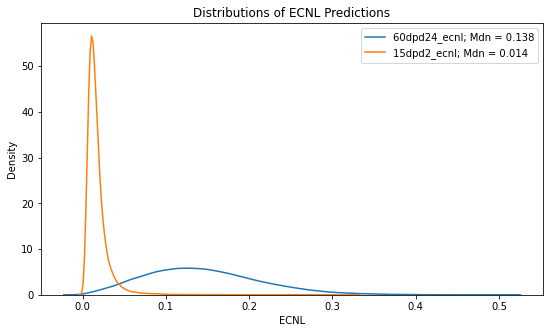

In [15]:
make_distplot(
    df=df,
    str_title='Distributions of ECNL Predictions',
)

#### BK

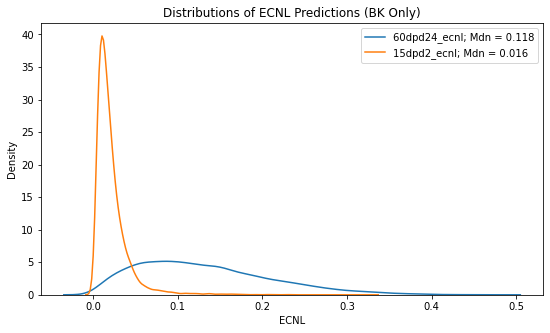

In [16]:
list_str_val = [
    '7.0',
    '13.0',
]
df_tmp = df[df['intopenbktype__app'].isin(list_str_val)].copy()
make_distplot(
    df=df_tmp,
    str_title='Distributions of ECNL Predictions (BK Only)',
)

#### Ch 7

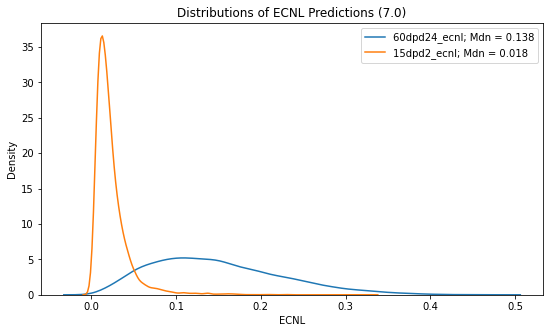

In [17]:
str_val = '7.0'
df_tmp = df[df['intopenbktype__app'] == str_val].copy()
make_distplot(
    df=df_tmp,
    str_title=f'Distributions of ECNL Predictions ({str_val})',
)

#### Ch 13

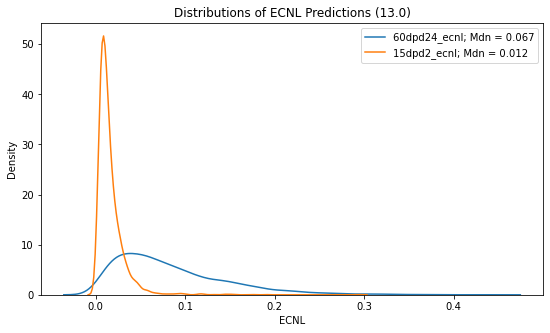

In [18]:
str_val = '13.0'
df_tmp = df[df['intopenbktype__app'] == str_val].copy()
make_distplot(
    df=df_tmp,
    str_title=f'Distributions of ECNL Predictions ({str_val})',
)

#### No BK

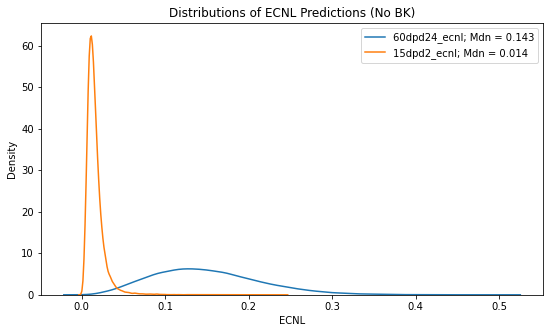

In [19]:
str_val = 'nan'
df_tmp = df[df['intopenbktype__app'] == str_val].copy()
make_distplot(
    df=df_tmp,
    str_title='Distributions of ECNL Predictions (No BK)',
)

### Compare relationships

#### All

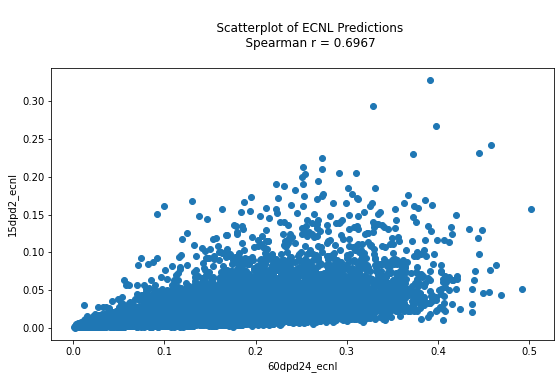

In [20]:
make_scatterplot(
    df=df, 
    str_title='Scatterplot of ECNL Predictions',
)

#### BK

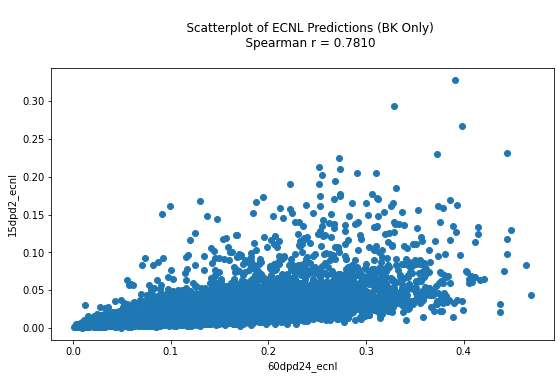

In [21]:
list_str_val = [
    '7.0',
    '13.0',
]
df_tmp = df[df['intopenbktype__app'].isin(list_str_val)].copy()
make_scatterplot(
    df=df_tmp, 
    str_title='Scatterplot of ECNL Predictions (BK Only)',
)

#### Ch 7

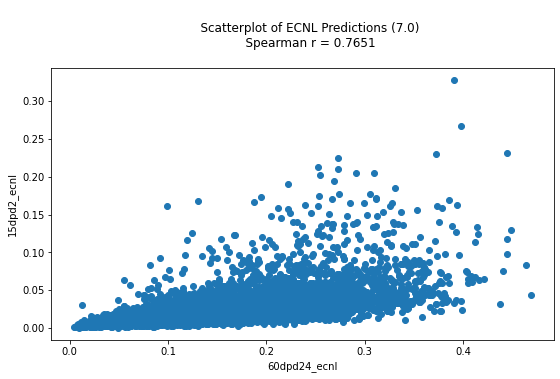

In [22]:
str_val = '7.0'
df_tmp = df[df['intopenbktype__app'] == str_val].copy()
make_scatterplot(
    df=df_tmp, 
    str_title=f'Scatterplot of ECNL Predictions ({str_val})',
)

#### Ch 13

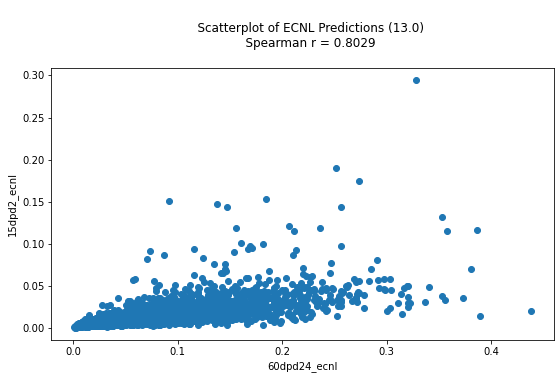

In [23]:
str_val = '13.0'
df_tmp = df[df['intopenbktype__app'] == str_val].copy()
make_scatterplot(
    df=df_tmp, 
    str_title=f'Scatterplot of ECNL Predictions ({str_val})',
)

#### No BK

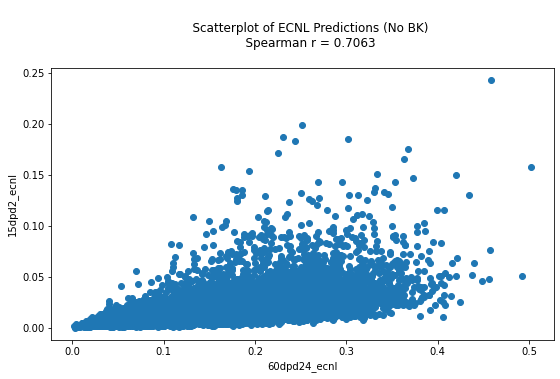

In [24]:
str_val = 'nan'
df_tmp = df[df['intopenbktype__app'] == str_val].copy()
make_scatterplot(
    df=df_tmp, 
    str_title='Scatterplot of ECNL Predictions (No BK)',
)

### Empty list for which to convert to df

In [25]:
list_dict_row = []

### Regression evaluation metrics

#### All

In [26]:
df_tmp, flt_score = get_metrics(df=df)
# dict_row
dict_row = {
    'Subset': 'All',
    'Transformation': 'None',
    'Factor': 'None',
    'Score': flt_score,
}
list_dict_row.append(dict_row)
# show
df_tmp

,Metric,Score
0,explained_variance,0.194178
1,mae,0.127042
2,mse,0.019902
3,rmse,0.141075


#### BK

In [27]:
list_str_val = [
    '7.0',
    '13.0',
]
df_tmp = df[df['intopenbktype__app'].isin(list_str_val)].copy()
df_tmp, flt_score = get_metrics(df=df_tmp)
# dict_row
dict_row = {
    'Subset': 'BK',
    'Transformation': 'None',
    'Factor': 'None',
    'Score': flt_score,
}
list_dict_row.append(dict_row)
# show
df_tmp

,Metric,Score
0,explained_variance,0.262239
1,mae,0.108926
2,mse,0.016387
3,rmse,0.128012


#### Ch 7

In [28]:
str_val = '7.0'
df_tmp = df[df['intopenbktype__app'] == str_val].copy()
df_tmp, flt_score = get_metrics(df=df_tmp)
# dict_row
dict_row = {
    'Subset': str_val,
    'Transformation': 'None',
    'Factor': 'None',
    'Score': flt_score,
}
list_dict_row.append(dict_row)
# show
df_tmp

,Metric,Score
0,explained_variance,0.271276
1,mae,0.124130
2,mse,0.019678
3,rmse,0.140280


#### Ch 13

In [29]:
str_val = '13.0'
df_tmp = df[df['intopenbktype__app'] == str_val].copy()
df_tmp, flt_score = get_metrics(df=df_tmp)
# dict_row
dict_row = {
    'Subset': str_val,
    'Transformation': 'None',
    'Factor': 'None',
    'Score': flt_score,
}
list_dict_row.append(dict_row)
# show
df_tmp

,Metric,Score
0,explained_variance,0.263223
1,mae,0.066661
2,mse,0.007238
3,rmse,0.085077


#### No BK

In [30]:
str_val = 'nan'
df_tmp = df[df['intopenbktype__app'] == str_val].copy()
df_tmp, flt_score = get_metrics(df=df_tmp)
# dict_row
dict_row = {
    'Subset': str_val,
    'Transformation': 'None',
    'Factor': 'None',
    'Score': flt_score,
}
list_dict_row.append(dict_row)
# show
df_tmp

,Metric,Score
0,explained_variance,0.178617
1,mae,0.133139
2,mse,0.021085
3,rmse,0.145207


### Find factors to add or subtract

In [31]:
flt_min = -1
flt_max = 1
list_flt_factor = list(np.linspace(flt_min, flt_max, int_n_vals))
# ensure zero is in
list_flt_factor = list_flt_factor + [0]
list_flt_factor = list(dict.fromkeys(list_flt_factor))
list_flt_factor.sort()

#### All

100%|█████████████████████████████████████████████████████████████████████████████| 1001/1001 [00:01<00:00, 834.88it/s]


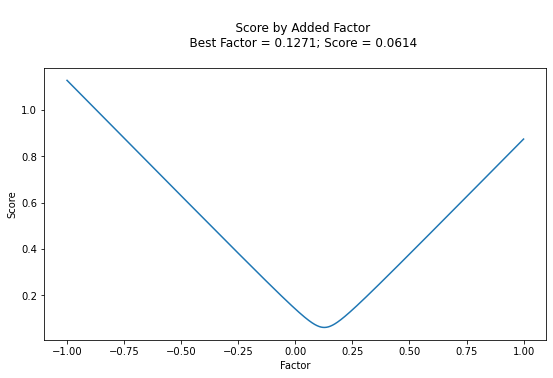

In [32]:
# show best factor
flt_score, flt_factor = show_best_added_factor(
    df=df,
    str_title='Score by Added Factor',
)
# dict_row
dict_row = {
    'Subset': 'All',
    'Transformation': 'Add',
    'Factor': flt_factor,
    'Score': flt_score,
}
list_dict_row.append(dict_row)

#### BK

100%|█████████████████████████████████████████████████████████████████████████████| 1001/1001 [00:01<00:00, 999.01it/s]


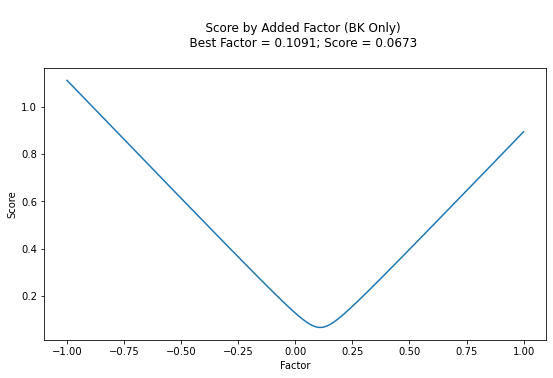

In [33]:
list_str_val = [
    '7.0',
    '13.0',
]
df_tmp = df[df['intopenbktype__app'].isin(list_str_val)].copy()
# show best factor
flt_score, flt_factor = show_best_added_factor(
    df=df_tmp,
    str_title='Score by Added Factor (BK Only)',
)
# dict_row
dict_row = {
    'Subset': 'BK',
    'Transformation': 'Add',
    'Factor': flt_factor,
    'Score': flt_score,
}
list_dict_row.append(dict_row)

#### Ch 7

100%|████████████████████████████████████████████████████████████████████████████| 1001/1001 [00:00<00:00, 1705.29it/s]


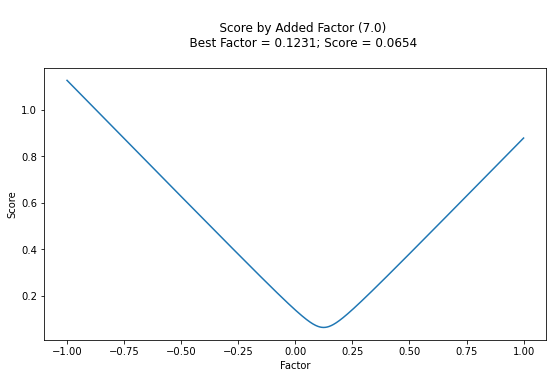

In [34]:
str_val = '7.0'
df_tmp = df[df['intopenbktype__app'] == str_val].copy()
# show best factor
flt_score, flt_factor = show_best_added_factor(
    df=df_tmp,
    str_title=f'Score by Added Factor ({str_val})',
)
# dict_row
dict_row = {
    'Subset': str_val,
    'Transformation': 'Add',
    'Factor': flt_factor,
    'Score': flt_score,
}
list_dict_row.append(dict_row)

#### Ch 13

100%|████████████████████████████████████████████████████████████████████████████| 1001/1001 [00:00<00:00, 1768.54it/s]


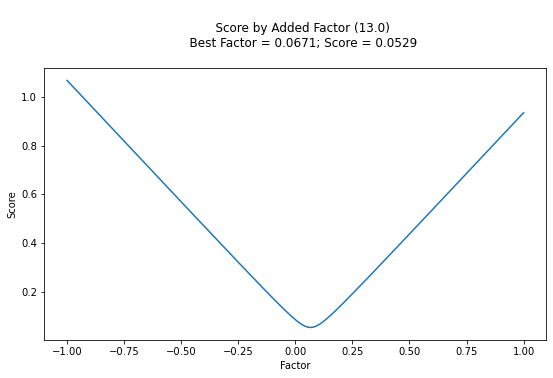

In [35]:
str_val = '13.0'
df_tmp = df[df['intopenbktype__app'] == str_val].copy()
# show best factor
flt_score, flt_factor = show_best_added_factor(
    df=df_tmp,
    str_title=f'Score by Added Factor ({str_val})',
)
# dict_row
dict_row = {
    'Subset': str_val,
    'Transformation': 'Add',
    'Factor': flt_factor,
    'Score': flt_score,
}
list_dict_row.append(dict_row)

#### No BK

100%|█████████████████████████████████████████████████████████████████████████████| 1001/1001 [00:01<00:00, 864.43it/s]


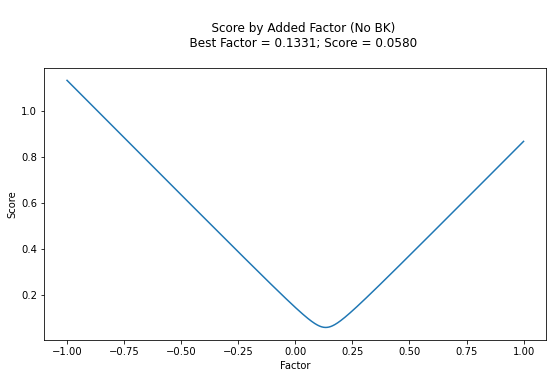

In [36]:
str_val = 'nan'
df_tmp = df[df['intopenbktype__app'] == str_val].copy()
# show best factor
flt_score, flt_factor = show_best_added_factor(
    df=df_tmp,
    str_title=f'Score by Added Factor (No BK)',
)
# dict_row
dict_row = {
    'Subset': str_val,
    'Transformation': 'Add',
    'Factor': flt_factor,
    'Score': flt_score,
}
list_dict_row.append(dict_row)

### Find multiplicative factors

In [37]:
flt_min = -3.0
flt_max = 15.0
list_flt_factor = list(np.linspace(flt_min, flt_max, int_n_vals))
# ensure zero is in
list_flt_factor = list_flt_factor + [0]
list_flt_factor = list(dict.fromkeys(list_flt_factor))
list_flt_factor.sort()

#### All

100%|█████████████████████████████████████████████████████████████████████████████| 1001/1001 [00:01<00:00, 843.31it/s]


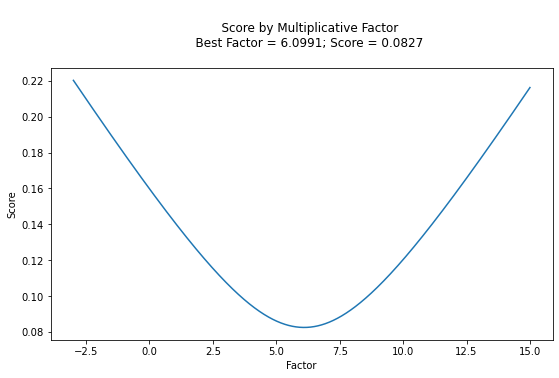

In [38]:
flt_score, flt_factor = show_best_multiplicative_factor(
    df=df, 
    str_title='Score by Multiplicative Factor',
)
# dict_row
dict_row = {
    'Subset': 'All',
    'Transformation': 'Multiply',
    'Factor': flt_factor,
    'Score': flt_score,
}
list_dict_row.append(dict_row)

#### BK

100%|█████████████████████████████████████████████████████████████████████████████| 1001/1001 [00:01<00:00, 812.51it/s]


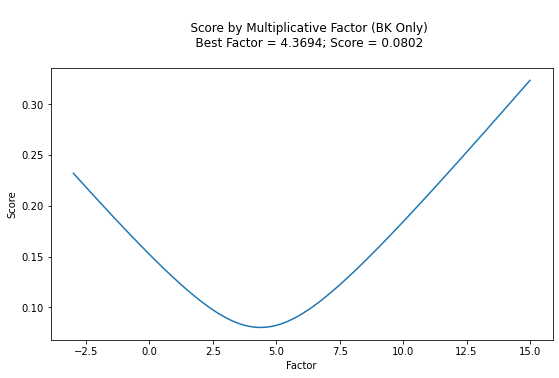

In [39]:
list_str_val = [
    '7.0',
    '13.0',
]
df_tmp = df[df['intopenbktype__app'].isin(list_str_val)].copy()
flt_score, flt_factor = show_best_multiplicative_factor(
    df=df_tmp, 
    str_title='Score by Multiplicative Factor (BK Only)',
)
# dict_row
dict_row = {
    'Subset': 'BK',
    'Transformation': 'Multiply',
    'Factor': flt_factor,
    'Score': flt_score,
}
list_dict_row.append(dict_row)

#### Ch 7

100%|████████████████████████████████████████████████████████████████████████████| 1001/1001 [00:00<00:00, 1491.82it/s]


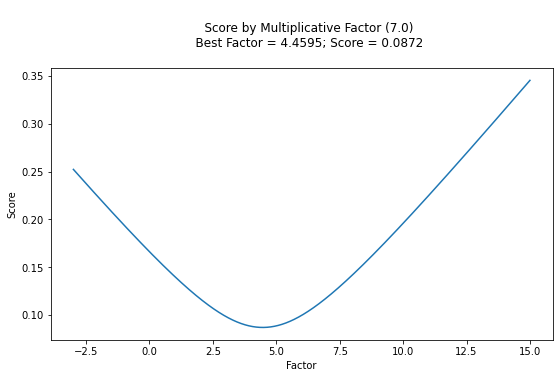

In [40]:
str_val = '7.0'
df_tmp = df[df['intopenbktype__app'] == str_val].copy()
flt_score, flt_factor = show_best_multiplicative_factor(
    df=df_tmp, 
    str_title=f'Score by Multiplicative Factor ({str_val})',
)
# dict_row
dict_row = {
    'Subset': str_val,
    'Transformation': 'Multiply',
    'Factor': flt_factor,
    'Score': flt_score,
}
list_dict_row.append(dict_row)

#### Ch 13

100%|████████████████████████████████████████████████████████████████████████████| 1001/1001 [00:00<00:00, 1255.99it/s]


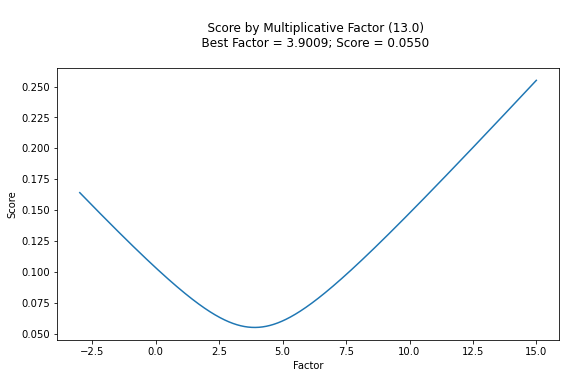

In [41]:
str_val = '13.0'
df_tmp = df[df['intopenbktype__app'] == str_val].copy()
flt_score, flt_factor = show_best_multiplicative_factor(
    df=df_tmp, 
    str_title=f'Score by Multiplicative Factor ({str_val})',
)
# dict_row
dict_row = {
    'Subset': str_val,
    'Transformation': 'Multiply',
    'Factor': flt_factor,
    'Score': flt_score,
}
list_dict_row.append(dict_row)

#### No BK

100%|█████████████████████████████████████████████████████████████████████████████| 1001/1001 [00:01<00:00, 773.58it/s]


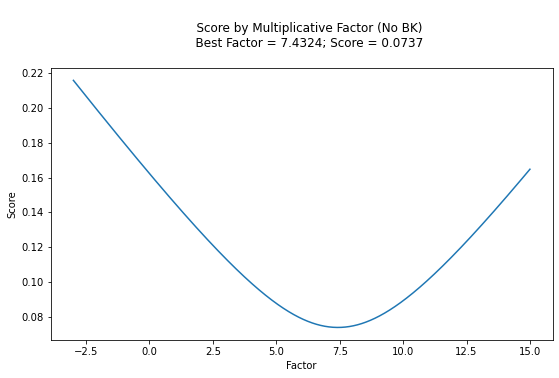

In [42]:
str_val = 'nan'
df_tmp = df[df['intopenbktype__app'] == str_val].copy()
flt_score, flt_factor = show_best_multiplicative_factor(
    df=df_tmp, 
    str_title=f'Score by Multiplicative Factor (No BK)',
)
# dict_row
dict_row = {
    'Subset': str_val,
    'Transformation': 'Multiply',
    'Factor': flt_factor,
    'Score': flt_score,
}
list_dict_row.append(dict_row)

### Simple linear regression

#### All

In [43]:
df_tmp = transformation_tuner(df=df)
# get factor
str_trans = df_tmp['Transformation'].iloc[0]
flt_int = df_tmp['Intercept'].iloc[0]
flt_beta = df_tmp['Coefficient'].iloc[0]
str_factor = f'{flt_int:0.4f} + ({flt_beta:0.4f} * 15dpd2_ecnl)'
flt_score = df_tmp['Score'].iloc[0]
# dict_row
dict_row = {
    'Subset': 'All',
    'Transformation': str_trans,
    'Factor': str_factor,
    'Score': flt_score,
}
list_dict_row.append(dict_row)

# show
df_tmp

100%|███████████████████████████████████████████████████████████████████████████████████| 8/8 [00:00<00:00, 101.27it/s]


,Transformation,Intercept,Coefficient,Score
1,Log,0.470762,0.076706,0.049242
2,Log10,0.470762,0.176623,0.049242
6,Cube_Root,-0.073421,0.880441,0.050001
4,Square_Root,0.008022,1.090075,0.051043
0,None,0.096337,2.764274,0.056047
7,Reciprocal,0.196531,-0.000611,0.056400
3,Square,0.138243,12.302911,0.065017
5,Cube,0.143501,31.976695,0.067569


#### BK

In [44]:
list_str_val = [
    '7.0',
    '13.0',
]
df_tmp = df[df['intopenbktype__app'].isin(list_str_val)].copy()
df_tmp = transformation_tuner(df=df_tmp)
# get factor
str_trans = df_tmp['Transformation'].iloc[0]
flt_int = df_tmp['Intercept'].iloc[0]
flt_beta = df_tmp['Coefficient'].iloc[0]
str_factor = f'{flt_int:0.4f} + ({flt_beta:0.4f} * 15dpd2_ecnl)'
flt_score = df_tmp['Score'].iloc[0]
# dict_row
dict_row = {
    'Subset': 'BK',
    'Transformation': str_trans,
    'Factor': str_factor,
    'Score': flt_score,
}
list_dict_row.append(dict_row)

# show
df_tmp

100%|███████████████████████████████████████████████████████████████████████████████████| 8/8 [00:00<00:00, 153.83it/s]


,Transformation,Intercept,Coefficient,Score
1,Log,0.455692,0.078833,0.051429
2,Log10,0.455692,0.181520,0.051429
6,Cube_Root,-0.098473,0.877631,0.051854
4,Square_Root,-0.014403,1.061756,0.053229
0,None,0.077173,2.472315,0.060378
7,Reciprocal,0.179997,-0.000603,0.063970
3,Square,0.121672,10.039909,0.072822
5,Cube,0.128571,26.990950,0.076732


#### Ch 7

In [45]:
str_val = '7.0'
df_tmp = df[df['intopenbktype__app'] == str_val].copy()
df_tmp = transformation_tuner(df=df_tmp)
# get factor
str_trans = df_tmp['Transformation'].iloc[0]
flt_int = df_tmp['Intercept'].iloc[0]
flt_beta = df_tmp['Coefficient'].iloc[0]
str_factor = f'{flt_int:0.4f} + ({flt_beta:0.4f} * 15dpd2_ecnl)'
flt_score = df_tmp['Score'].iloc[0]
# dict_row
dict_row = {
    'Subset': str_val,
    'Transformation': str_trans,
    'Factor': str_factor,
    'Score': flt_score,
}
list_dict_row.append(dict_row)
# show
df_tmp

100%|███████████████████████████████████████████████████████████████████████████████████| 8/8 [00:00<00:00, 186.05it/s]


,Transformation,Intercept,Coefficient,Score
2,Log10,0.463013,0.180500,0.051200
1,Log,0.463013,0.078390,0.051200
6,Cube_Root,-0.078634,0.839861,0.051863
4,Square_Root,0.004675,0.999599,0.053199
0,None,0.094658,2.253971,0.059694
7,Reciprocal,0.197561,-0.000685,0.062516
3,Square,0.138190,9.343152,0.070965
5,Cube,0.145431,26.584101,0.074822


#### Ch 13

In [46]:
str_val = '13.0'
df_tmp = df[df['intopenbktype__app'] == str_val].copy()
df_tmp = transformation_tuner(df=df_tmp)
# get factor
str_trans = df_tmp['Transformation'].iloc[0]
flt_int = df_tmp['Intercept'].iloc[0]
flt_beta = df_tmp['Coefficient'].iloc[0]
str_factor = f'{flt_int:0.4f} + ({flt_beta:0.4f} * 15dpd2_ecnl)'
flt_score = df_tmp['Score'].iloc[0]
# dict_row
dict_row = {
    'Subset': str_val,
    'Transformation': str_trans,
    'Factor': str_factor,
    'Score': flt_score,
}
list_dict_row.append(dict_row)
# show
df_tmp

100%|███████████████████████████████████████████████████████████████████████████████████| 8/8 [00:00<00:00, 173.93it/s]


,Transformation,Intercept,Coefficient,Score
6,Cube_Root,-0.099769,0.769780,0.040551
2,Log10,0.356962,0.143182,0.041077
1,Log,0.356962,0.062183,0.041077
4,Square_Root,-0.033178,0.980897,0.041278
0,None,0.041238,2.570222,0.046974
7,Reciprocal,0.122277,-0.000366,0.051247
3,Square,0.078087,9.271792,0.058313
5,Cube,0.082041,20.056284,0.060873


#### No BK

In [47]:
str_val = 'nan'
df_tmp = df[df['intopenbktype__app'] == str_val].copy()
df_tmp = transformation_tuner(df=df_tmp)
# get factor
str_trans = df_tmp['Transformation'].iloc[0]
flt_int = df_tmp['Intercept'].iloc[0]
flt_beta = df_tmp['Coefficient'].iloc[0]
str_factor = f'{flt_int:0.4f} + ({flt_beta:0.4f} * 15dpd2_ecnl)'
flt_score = df_tmp['Score'].iloc[0]
# dict_row
dict_row = {
    'Subset': str_val,
    'Transformation': str_trans,
    'Factor': str_factor,
    'Score': flt_score,
}
list_dict_row.append(dict_row)
# show
df_tmp

100%|████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:00<00:00, 56.34it/s]


,Transformation,Intercept,Coefficient,Score
1,Log,0.492125,0.079810,0.045728
2,Log10,0.492125,0.183769,0.045728
6,Cube_Root,-0.082711,0.954399,0.046106
4,Square_Root,0.001584,1.216035,0.046869
0,None,0.093479,3.478062,0.051048
7,Reciprocal,0.202804,-0.000622,0.052542
3,Square,0.141147,21.110126,0.060111
5,Cube,0.148014,71.905316,0.063076


### Conclusion

In [48]:
# make df
df_tmp = pd.DataFrame(list_dict_row)
# get unique vals
list_str_subset = list(df_tmp['Subset'].value_counts().index)
# iterate and subset
for str_subset in list_str_subset:
    # logic
    if str_subset == 'nan':
        print(f'Subset: No BK')
    else:
        print(f'Subset: {str_subset}')
    df_sub = df_tmp[df_tmp['Subset'] == str_subset].copy()
    # sort
    df_sub.sort_values(by='Score', ascending=True, inplace=True)
    # subset
    list_cols = [col for col in df_sub.columns if col != 'Subset']
    df_sub = df_sub[list_cols].copy()
    # show
    print(df_sub)
    # print empty line
    print('')

Subset: No BK
   Transformation                           Factor     Score
19            Log  0.4921 + (0.0798 * 15dpd2_ecnl)  0.045728
9             Add                         0.133133  0.057957
14       Multiply                         7.432432  0.073723
4            None                             None  0.145207

Subset: All
   Transformation                           Factor     Score
15            Log  0.4708 + (0.0767 * 15dpd2_ecnl)  0.049242
5             Add                         0.127127  0.061358
10       Multiply                         6.099099  0.082687
0            None                             None  0.141075

Subset: BK
   Transformation                           Factor     Score
16            Log  0.4557 + (0.0788 * 15dpd2_ecnl)  0.051429
6             Add                         0.109109  0.067309
11       Multiply                         4.369369  0.080206
1            None                             None  0.128012

Subset: 13.0
   Transformation               